# Keyword Extraction & Interpretability in Movie Review Sentiment Analysis

## Introduction

Sentiment classifiers can predict whether a movie review is positive or negative, but they do not directly explain *why* the model made a prediction.

This notebook extends the existing sentiment analysis pipeline by adding **keyword extraction** with TF-IDF signals to improve interpretability. It is designed as a direct continuation of the project, alongside the emotion detection extension.

## Load Dataset

In [1]:
# Core imports aligned with the project stack
from pathlib import Path
import re
from collections import Counter

import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 140)

In [2]:
# Load IMDb dataset using the same structure as the main notebook
dataset_path = Path("../data/IMDB Dataset.csv")
if not dataset_path.exists():
    dataset_path = Path("data/IMDB Dataset.csv")

df = pd.read_csv(dataset_path)
print(f"Loaded dataset shape: {df.shape}")
df[["review", "sentiment"]].head()

Loaded dataset shape: (50000, 2)


,review,sentiment
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what...",positive
1,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, a...",positive
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a ligh...",positive
3,Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is a visually stunning film to watch. Mr. Mattei offers us a vivid portrait about human rela...",positive


## Text Preprocessing (Reuse Logic)

In [3]:
# Reuse the same clean_text logic pattern used in the main project
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def clean_text(text: str) -> str:
    """Lowercase text, remove HTML tags/special characters, and drop stopwords."""
    text = str(text).lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = [token for token in text.split() if token not in stop_words]
    return " ".join(tokens)

df["clean_review"] = df["review"].apply(clean_text)
df[["review", "clean_review"]].head(3)

,review,clean_review
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what...",one reviewers mentioned watching oz episode hooked right exactly happened first thing struck oz brutality unflinching scenes violence se...
1,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, a...",wonderful little production filming technique unassuming old time bbc fashion gives comforting sometimes discomforting sense realism ent...
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a ligh...",thought wonderful way spend time hot summer weekend sitting air conditioned theater watching light hearted comedy plot simplistic dialog...


## Sampling

In [4]:
# Use a laptop-friendly subset for faster experimentation
sample_size = 800  # requested range: 500-1000
sample_df = df.sample(n=min(sample_size, len(df)), random_state=42).copy()

# Normalize sentiment to project convention: positive=1, negative=0
if pd.api.types.is_numeric_dtype(sample_df["sentiment"]):
    sample_df["sentiment"] = sample_df["sentiment"].astype(int)
else:
    sample_df["sentiment"] = (
        sample_df["sentiment"]
        .astype(str)
        .str.strip()
        .str.lower()
        .map({"positive": 1, "negative": 0})
    )

if sample_df["sentiment"].isna().any():
    raise ValueError("Unexpected sentiment labels found.")

print(f"Sampled rows: {len(sample_df)}")
sample_df["sentiment"].value_counts()

Sampled rows: 800


sentiment
0    413
1    387
Name: count, dtype: int64

## TF-IDF Feature Extraction (Aligned With Main Project)

In [5]:
# Same vectorization strategy as the main sentiment notebook
vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = vectorizer.fit_transform(sample_df["clean_review"])
feature_names = vectorizer.get_feature_names_out()

print(f"TF-IDF matrix shape: {X_tfidf.shape}")

TF-IDF matrix shape: (800, 5000)


## Keyword Extraction Function

In [6]:
def get_top_keywords(vector, feature_names, top_n=5):
    """Return top-N keywords for one TF-IDF row vector based on highest scores."""
    if vector.nnz == 0:
        return []

    scores = vector.data
    indices = vector.indices

    # Get indices of largest TF-IDF scores inside this sparse row
    top_local_idx = np.argsort(scores)[-top_n:][::-1]
    top_feature_idx = indices[top_local_idx]
    return feature_names[top_feature_idx].tolist()

## Apply Keyword Extraction

In [7]:
# Extract keywords per review and store in the dataframe
sample_df["keywords_list"] = [
    get_top_keywords(X_tfidf[i], feature_names, top_n=5)
    for i in range(X_tfidf.shape[0])
]
sample_df["keywords"] = sample_df["keywords_list"].apply(lambda x: ", ".join(x))

sample_df[["clean_review", "keywords"]].head()

,clean_review,keywords
33553,really liked summerslam due look arena curtains look overall interesting reason anyways could one best summerslam ever wwf lex luger mai...,"vs, match, event, terrible, summerslam"
9427,many television shows appeal quite many different kinds fans like farscape know youngsters years old fans male female many different cou...,"farscape, many, pilot, multiple, keep"
199,film quickly gets major chase scene ever increasing destruction first really bad thing guy hijacking steven seagal would beaten pulp sea...,"seagal, steven, destruction, coherent, pulp"
12447,jane austen would definitely approve one gwyneth paltrow awesome job capturing attitude emma funny without excessively silly yet elegant...,"emma, law, british, sliding, capturing"
39489,expectations somewhat high went see movie thought steve carell could wrong coming great movies like anchorman year old virgin little mis...,"carell, steve, family, wrong, almost"


## Analysis

In [8]:
# A) Global keyword trends from aggregate TF-IDF importance
global_scores = np.asarray(X_tfidf.sum(axis=0)).ravel()
global_top_idx = np.argsort(global_scores)[-15:][::-1]
global_keywords_df = pd.DataFrame({
    "keyword": feature_names[global_top_idx],
    "score": global_scores[global_top_idx]
})

# B) Sentiment-wise keyword analysis
positive_mask = sample_df["sentiment"] == 1
negative_mask = sample_df["sentiment"] == 0

positive_scores = np.asarray(X_tfidf[positive_mask.values].sum(axis=0)).ravel()
negative_scores = np.asarray(X_tfidf[negative_mask.values].sum(axis=0)).ravel()

pos_top_idx = np.argsort(positive_scores)[-12:][::-1]
neg_top_idx = np.argsort(negative_scores)[-12:][::-1]

positive_keywords_df = pd.DataFrame({
    "keyword": feature_names[pos_top_idx],
    "score": positive_scores[pos_top_idx]
})
negative_keywords_df = pd.DataFrame({
    "keyword": feature_names[neg_top_idx],
    "score": negative_scores[neg_top_idx]
})

display(global_keywords_df.head(10))
display(positive_keywords_df.head(10))
display(negative_keywords_df.head(10))

,keyword,score
0,movie,44.435300
1,film,39.172792
2,one,25.859417
3,like,22.565978
4,good,19.251332
5,see,16.973684
6,even,16.254724
7,time,15.707882
8,would,15.498299
9,bad,15.332506


,keyword,score
0,film,20.685191
1,movie,17.925899
2,one,13.222916
3,like,9.662249
4,great,9.055073
5,see,9.034301
6,good,8.970793
7,well,8.674292
8,also,8.329610
9,best,8.286685


,keyword,score
0,movie,26.509401
1,film,18.487601
2,like,12.903730
3,one,12.636501
4,bad,12.366722
5,good,10.280539
6,even,10.204565
7,would,9.702627
8,really,8.548298
9,much,8.531177


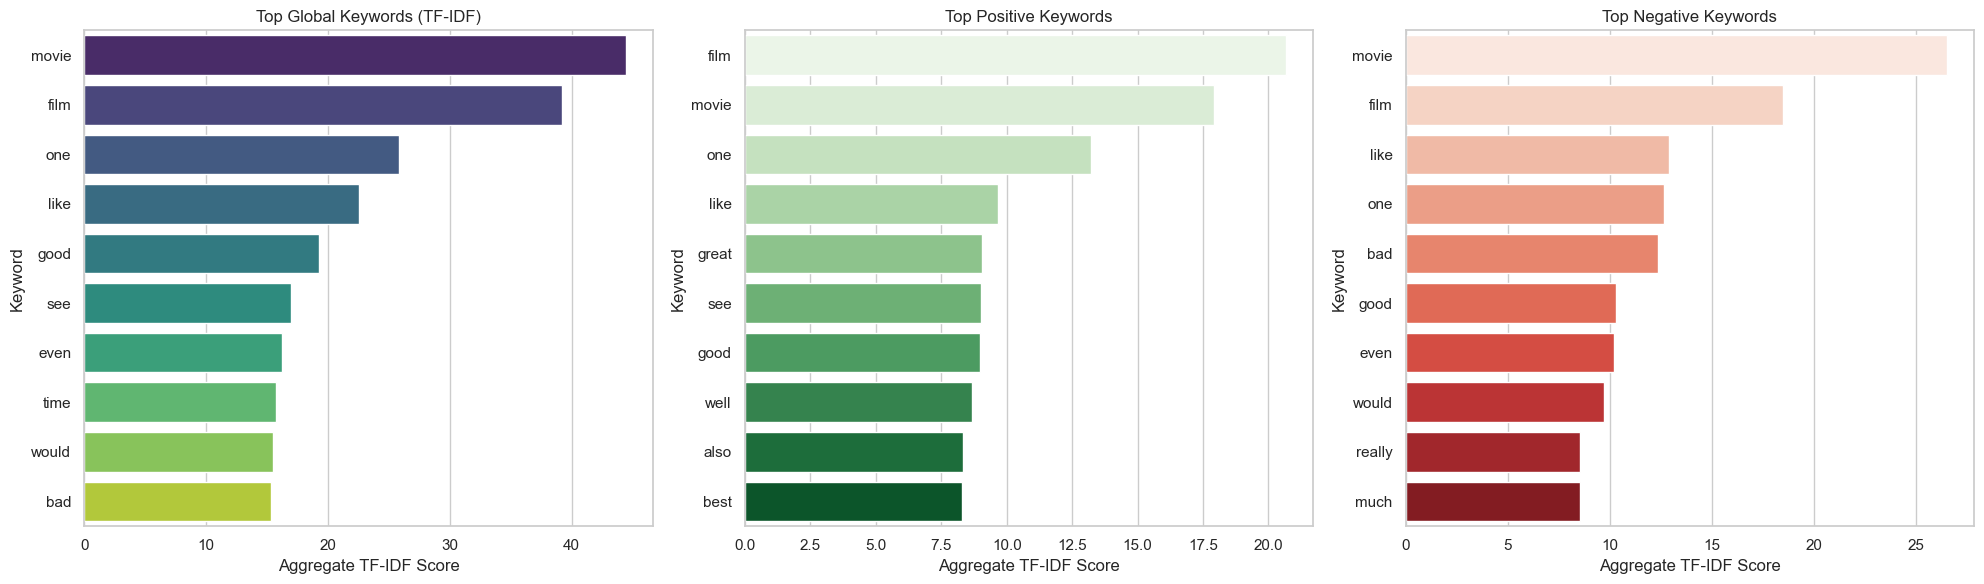

In [9]:
# C) Visualization of keyword trends and sentiment comparison
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.barplot(
    data=global_keywords_df.head(10),
    y="keyword",
    x="score",
    hue="keyword",
    legend=False,
    palette="viridis",
    ax=axes[0]
)
axes[0].set_title("Top Global Keywords (TF-IDF)")
axes[0].set_xlabel("Aggregate TF-IDF Score")
axes[0].set_ylabel("Keyword")

sns.barplot(
    data=positive_keywords_df.head(10),
    y="keyword",
    x="score",
    hue="keyword",
    legend=False,
    palette="Greens",
    ax=axes[1]
)
axes[1].set_title("Top Positive Keywords")
axes[1].set_xlabel("Aggregate TF-IDF Score")
axes[1].set_ylabel("Keyword")

sns.barplot(
    data=negative_keywords_df.head(10),
    y="keyword",
    x="score",
    hue="keyword",
    legend=False,
    palette="Reds",
    ax=axes[2]
)
axes[2].set_title("Top Negative Keywords")
axes[2].set_xlabel("Aggregate TF-IDF Score")
axes[2].set_ylabel("Keyword")

plt.tight_layout()
plt.show()

## Results & Insights

In [10]:
# Display review | sentiment | keywords
display(sample_df[["review", "sentiment", "keywords"]].head(10))

# Compact interpretability summary
positive_vocab = Counter(word for kw in sample_df.loc[sample_df["sentiment"] == 1, "keywords_list"] for word in kw)
negative_vocab = Counter(word for kw in sample_df.loc[sample_df["sentiment"] == 0, "keywords_list"] for word in kw)

print("Top positive-side keywords:")
print(pd.DataFrame(positive_vocab.most_common(10), columns=["keyword", "count"]))
print()
print("Top negative-side keywords:")
print(pd.DataFrame(negative_vocab.most_common(10), columns=["keyword", "count"]))
print()
print("Interpretation:")
print("- Positive reviews often surface appreciation-oriented words (for example: great, amazing, excellent).")
print("- Negative reviews often surface dissatisfaction-oriented words (for example: bad, boring, worst).")
print("- Keyword extraction improves interpretability by exposing themes that likely drive sentiment predictions.")

,review,sentiment,keywords
33553,"I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reaso...",1,"vs, match, event, terrible, summerslam"
9427,Not many television shows appeal to quite as many different kinds of fans like Farscape does...I know youngsters and 30/40+ years old;fa...,1,"farscape, many, pilot, multiple, keep"
199,The film quickly gets to a major chase scene with ever increasing destruction. The first really bad thing is the guy hijacking Steven Se...,0,"seagal, steven, destruction, coherent, pulp"
12447,Jane Austen would definitely approve of this one!<br /><br />Gwyneth Paltrow does an awesome job capturing the attitude of Emma. She is ...,1,"emma, law, british, sliding, capturing"
39489,"Expectations were somewhat high for me when I went to see this movie, after all I thought Steve Carell could do no wrong coming off of g...",0,"carell, steve, family, wrong, almost"
42724,"I've watched this movie on a fairly regular basis for most of my life, and it never gets old. For all the snide remarks and insults (mos...",1,"farley, tommy, spade, chris, company"
10822,"For once a story of hope highlighted over the tragic reality our youth face. Favela Rising draws one into a scary, unsafe and unfair wor...",1,"beautiful, world, anderson, dedicated, unfair"
49498,"Okay, I didn't get the Purgatory thing the first time I watched this episode. It seemed like something significant was going on that I c...",1,"tony, purgatory, heaven, monks, slap"
4144,I was very disappointed with this series. It had lots of cool graphics and that's about it. The level of detail it went into was minimal...,0,"examples, detail, host, explain, cool"
36958,"The first 30 minutes of Tinseltown had my finger teetering on the remote, poised to flick around to watch something else. The premise of...",0,"tinseltown, laughed, scenes, luck, introduction"


Top positive-side keywords:
  keyword  count
0    film     17
1   movie     15
2    show     10
3  series     10
4  family      8
5   great      6
6    best      6
7    love      6
8     sex      5
9  action      5

Top negative-side keywords:
    keyword  count
0     movie     29
1      film     16
2      show     16
3       bad     11
4     funny      8
5       guy      7
6  terrible      6
7      book      6
8        tv      6
9    series      5

Interpretation:
- Positive reviews often surface appreciation-oriented words (for example: great, amazing, excellent).
- Negative reviews often surface dissatisfaction-oriented words (for example: bad, boring, worst).
- Keyword extraction improves interpretability by exposing themes that likely drive sentiment predictions.


## Project Integration

This notebook extends the sentiment analysis project by adding an interpretability layer through keyword extraction.

The combined system now includes:
- Sentiment classification (main notebook)
- Emotion detection (extension 1)
- Keyword extraction (extension 2)

Together, these three components provide deeper insights: polarity, emotional nuance, and the specific terms/themes likely driving model behavior.

## Requirements Check

In [11]:
# Verify notebook dependencies are present in requirements.txt
required_libraries = {
    "pandas",
    "numpy",
    "matplotlib",
    "seaborn",
    "nltk",
    "scikit-learn"
}

req_path = Path("../requirements.txt")
if not req_path.exists():
    req_path = Path("requirements.txt")

raw_lines = req_path.read_text(encoding="utf-8").splitlines()
installed_names = set()

for line in raw_lines:
    item = line.strip()
    if not item or item.startswith("#"):
        continue

    base = re.split(r"[<>=!~]", item, maxsplit=1)[0].strip().lower()
    if base:
        installed_names.add(base)

missing = sorted(lib for lib in required_libraries if lib.lower() not in installed_names)

print("Libraries used in this notebook:")
print(sorted(required_libraries))
print()

if missing:
    print("Missing from requirements.txt:")
    for lib in missing:
        print(f"- {lib}")
else:
    print("All required libraries are present in requirements.txt.")

Libraries used in this notebook:
['matplotlib', 'nltk', 'numpy', 'pandas', 'scikit-learn', 'seaborn']

All required libraries are present in requirements.txt.
